# Build Event Catalog

Build the 500-event runnable design catalog, derived from a larger candidate pool, and the flood-forcing stress set for SFINCS depth profiles that drive risk and DNMG contingency-operation studies.

In [1]:
# imports, workspace path, and catalog runtime.
import sys
from pathlib import Path

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from pyextremes import get_extremes
import pyvinecopulib as pvc

# distribution, severity, and scaling plots.
from design_events import plotting as P
# paths and severity bands.
from design_events.build_events.workflow import assign_severity_bands, load_runtime
# historical water levels for coastal event statistics.
from design_events.fit_history.peaks import load_hourly_waterlevel
# turn historical peaks into auditable frequency tables.
from design_events.fit_history.return_curve import HistoricalPeakMarginal, marginal_params_frame, marginal_rps_frame
# stress-event selection and Wflow/SFINCS inputs.
from design_events.build_events.workflow import (
    attach_antecedent_soil_moisture,
    select_training,
)
# pair observed forcings and build member libraries for catalog sampling.
from design_events.fit_history.driver_records import assemble_paired_observations_from_config, build_member_libraries
# inland/joint design-event catalogs and historical-tail samples.
from design_events.build_events.probability.design_catalog import build_tail, build_joint_catalog
# packages coastal catalog forcing for SFINCS scenarios.
from sfincs_runs.scenarios.joint_handoff import write_handoff

pd.set_option("display.max_columns", 80)
plt.style.use("seaborn-v0_8-whitegrid")

runtime = load_runtime(location_root)
config = runtime.config
paths = runtime.runtime_paths
location_name = runtime.location_name


/home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype: align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
 array = pickle.load(fp, **pickle_kwargs)


## Stage 1 — Source inventory

Parameters surfaced here:
- Rainfall members use seasonal-window permutation
- Soil moisture is attached as antecedent state 24 hours before the rainfall/coastal forcing reference.
- Streamflow is intentionally absent for Marshfield (lack of gages, little impact)

In [2]:
# source inventory and pairing policy for coastal catalog.
forcing_member_paths = {
    "rainfall": "data/sources/aorc_sst/rainfall_members.csv",
    "streamflow": None,
    "soil_moisture": "data/sources/nwm/soil_moisture.csv",
}
pairing_policy = {
    "rainfall": {"strategy": "seasonal_window_permutation", "seed": 2, "window_days": 45},
    "streamflow": {"strategy": "seasonal_window_permutation", "seed": 3, "window_days": 45},
    "soil_moisture": {
        "strategy": "antecedent_to_forcing",
        "reference_forcing": "rainfall",
        "lead_time_hours": 24,
    },
}
config.setdefault("event_catalog", {})["forcing_members"] = forcing_member_paths
config["event_catalog"]["pairing"] = pairing_policy

def source_artifact_status(filename):
    path = paths["source_artifacts_root"] / filename
    if not path.exists():
        return "missing"
    return str(json.loads(path.read_text(encoding="utf-8")).get("status", "unknown"))

source_inventory_frame = pd.DataFrame([
    {
        "driver": "coastal_water_level",
        "source": "CORA boundary-node hourly water level",
        "role": "coastal event-index marginal, NTR/surge axis, and tide-preserving templates",
        "pairing_policy": "event_index",
        "path": str(paths["waterlevel_csv"]),
        "status": source_artifact_status("cora_boundary_water_level.json"),
    },
    {
        "driver": "coastal_waves",
        "source": "ERA5/SnapWave boundary forcing",
        "role": "wave forcing from the same historical coastal analog",
        "pairing_policy": "same_historical_analog",
        "path": str(paths["era5_waves_nc"]),
        "status": source_artifact_status("era5_snapwave_boundary_forcing.json"),
    },
    {
        "driver": "rainfall",
        "source": "Direct AORC SST",
        "role": "stochastic storm transposition rainfall members",
        "pairing_policy": pairing_policy["rainfall"]["strategy"],
        "path": str(paths["aorc_sst_rainfall_members_csv"]),
        "status": source_artifact_status("aorc_sst_rainfall_catalog.json"),
    },
    {
        "driver": "soil_moisture",
        "source": "NWM retrospective",
        "role": "antecedent hydrologic state for paired rainfall members",
        "pairing_policy": pairing_policy["soil_moisture"]["strategy"],
        "path": str(paths["nwm_soil_moisture_csv"]),
        "status": source_artifact_status("nwm_retrospective_hydrologic_state.json"),
    },
    {
        "driver": "streamflow",
        "source": "not used",
        "role": "not a configured boundary driver for the coastal Marshfield catalog",
        "pairing_policy": "not_required",
        "path": None,
        "status": "not_required",
    },
])

source_inventory = source_inventory_frame
display(source_inventory_frame)
display(pd.Series({
    "location": location_name,
    "rainfall_pairing_seed": pairing_policy["rainfall"]["seed"],
    "rainfall_pairing_window_days": pairing_policy["rainfall"]["window_days"],
    "soil_moisture_lead_time_hours": pairing_policy["soil_moisture"]["lead_time_hours"],
}, name="source_pairing_parameters"))


,driver,source,role,pairing_policy,path,status
0,coastal_water_level,CORA boundary-node hourly water level,"coastal event-index marginal, NTR/surge axis,...",event_index,/home/grahamhults/projects/Flood-RM/locations/...,complete
1,coastal_waves,ERA5/SnapWave boundary forcing,wave forcing from the same historical coastal...,same_historical_analog,/home/grahamhults/projects/Flood-RM/locations/...,complete
2,rainfall,Direct AORC SST,stochastic storm transposition rainfall members,seasonal_window_permutation,/home/grahamhults/projects/Flood-RM/locations/...,complete
3,soil_moisture,NWM retrospective,antecedent hydrologic state for paired rainfal...,antecedent_to_forcing,/home/grahamhults/projects/Flood-RM/locations/...,complete
4,streamflow,not used,not a configured boundary driver for the coast...,not_required,NaN,not_required


location marshfield
rainfall_pairing_seed 2
rainfall_pairing_window_days 45
soil_moisture_lead_time_hours 24
Name: source_pairing_parameters, dtype: object

## Stage 2 — Driver libraries and marginal evidence

CORA supplies the coastal water-level frequency axis used for Coastal Driver Return Period labels and same-analog wave timing. 

Direct AORC SST supplies rainfall members. 

NWM supplies antecedent wetness. 

ERA5/SnapWave metadata stays tied to the same historical coastal analog as the CORA template. 

The catalog is therefore driver-first and pairing-explicit, not a univariate flood model.

- Total water level is used as the boundary condition, but the dependence driver is the non-tidal residual (NTR).
- Marginal diagnostics transform observed peaks into return periods through fitted exceedance distributions.
- Soil moisture is retained as antecedent state, not a copula axis.

### 2.1 Driver Member Libraries

,driver,source,status,member_rows
0,coastal water level,CORA,complete,NaN
1,rainfall,Direct AORC SST,complete,440.0
2,antecedent soil moisture,NWM retrospective,complete,2566240.0
3,coastal waves,ERA5/SnapWave same coastal analog,complete,NaN


,member_id,source,member_file,storm_start,storm_end,duration_hours,rank,annual_rank,mean_precip_mm,max_precip_mm,min_precip_mm,precip_units,potential_method,centroid_lon,centroid_lat,historical_centroid_lon,historical_centroid_lat,transposed_centroid_lon,transposed_centroid_lat,transposition_offset_lon,transposition_offset_lat,transposition_region_id
0,rainfall_marshfield_72h_rank0001,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2006-05-13T06:00:00,2006-05-16T06:00:00,72,1,1,297.733933,314.900005,279.300004,mm,moving_footprint_max_mean,-70.844033,42.815754,-71.036200,42.195857,-70.844033,42.815754,0.192167,0.619897,east-atlantic-marshfield
1,rainfall_marshfield_72h_rank0002,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,1996-10-19T12:00:00,1996-10-22T12:00:00,72,2,1,240.052682,254.600004,224.300003,mm,moving_footprint_max_mean,-70.910697,42.815754,-71.072850,42.103122,-70.910697,42.815754,0.162153,0.712632,east-atlantic-marshfield
2,rainfall_marshfield_72h_rank0003,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2010-03-13T06:00:00,2010-03-16T06:00:00,72,3,1,224.723218,228.800003,220.600003,mm,moving_footprint_max_mean,-70.977361,42.682426,-71.109667,42.092021,-70.977361,42.682426,0.132306,0.590405,east-atlantic-marshfield
3,rainfall_marshfield_72h_rank0004,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2011-08-25T18:00:00,2011-08-28T18:00:00,72,4,1,217.901789,251.600004,187.300003,mm,moving_footprint_max_mean,-71.644001,42.115782,-71.370290,42.202351,-71.644001,42.115782,-0.273711,-0.086569,east-atlantic-marshfield
4,rainfall_marshfield_72h_rank0005,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2005-10-13T00:00:00,2005-10-16T00:00:00,72,5,1,217.861610,228.100003,202.500003,mm,moving_footprint_max_mean,-71.344013,41.682466,-71.181427,41.967042,-71.344013,41.682466,-0.162586,-0.284576,east-atlantic-marshfield


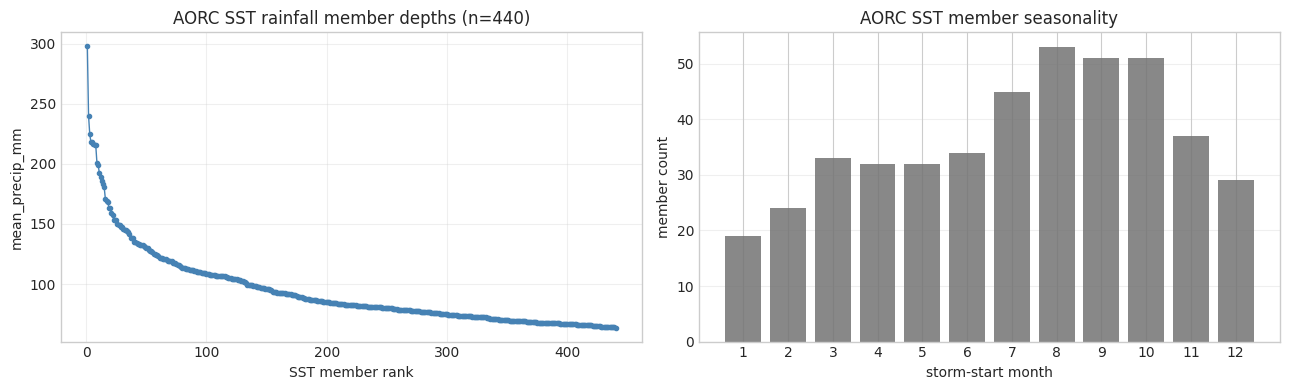

In [3]:
# driver member libraries for catalog sampling.
rainfall_members = pd.read_csv(paths["aorc_sst_rainfall_members_csv"])
soil_moisture_members = pd.read_csv(paths["nwm_soil_moisture_csv"])
# Carry the NWM source path on the frame so antecedent soil pairing can stamp
# soil_moisture_member_file onto each member (pd.read_csv drops DataFrame.attrs).
soil_moisture_members.attrs["source_file"] = str(paths["nwm_soil_moisture_csv"])

status_by_driver = source_inventory.set_index("driver")["status"].to_dict()
driver_library_summary = pd.DataFrame([
    {"driver": "coastal water level", "source": "CORA", "status": status_by_driver.get("coastal_water_level")},
    {"driver": "rainfall", "source": "Direct AORC SST", "status": status_by_driver.get("rainfall"), "member_rows": len(rainfall_members)},
    {"driver": "antecedent soil moisture", "source": "NWM retrospective", "status": status_by_driver.get("soil_moisture"), "member_rows": len(soil_moisture_members)},
    {"driver": "coastal waves", "source": "ERA5/SnapWave same coastal analog", "status": status_by_driver.get("coastal_waves")},
])
display(driver_library_summary)
P.plot_rainfall(rainfall_members);
rainfall_members.head(5)


### 2.2 Coastal Water-Level Marginal Evidence

At a macro-tidal site the total-water-level peak is tide-saturated, so the coastal driver fed to the copula is the non-tidal residual (surge), fit in 2.2.8. Tide timing for wave forcing still uses the same historical coastal analog.

Reviewer distinction:
- Total still water level answers: what water level did the coast experience?
- NTR answers: what meteorological surge driver should be paired with rainfall?

### 2.2.1 Raw CORA Hourly Water Level


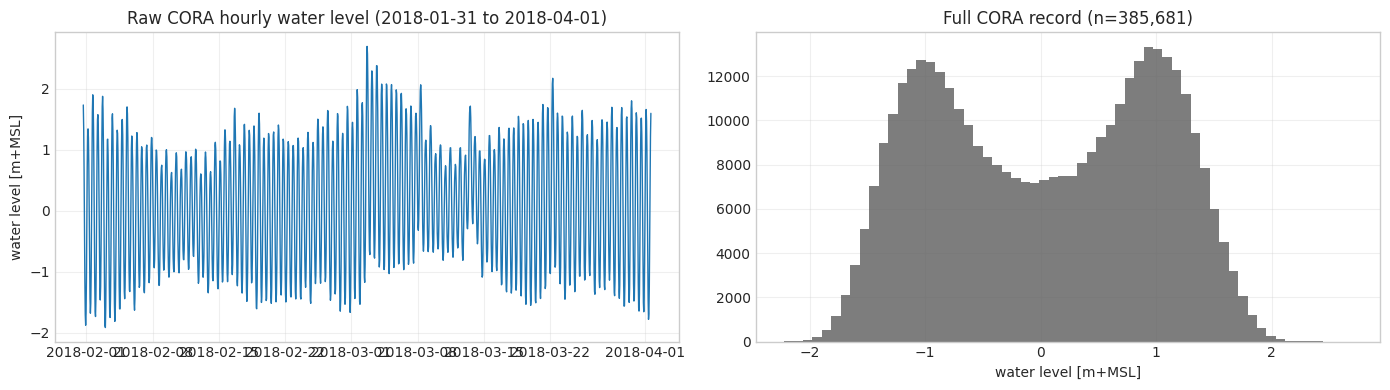

waterlevel_rows 385681
waterlevel_start 1979-01-01 00:00:00
waterlevel_end 2022-12-31 00:00:00
raw_record_max_m 2.69103
raw_record_peak_time 2018-03-02 16:00:00
Name: cora_waterlevel_record, dtype: object

In [4]:
# observed water levels for coastal POT evidence.
waterlevel = load_hourly_waterlevel(paths["waterlevel_csv"]).dropna().sort_index()
peak_time = waterlevel.idxmax()
window_slice = (peak_time - pd.Timedelta(days=30), peak_time + pd.Timedelta(days=30))
window = waterlevel.loc[window_slice[0]:window_slice[1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(window.index, window.values, lw=1.0)
axes[0].set_title(f"Raw CORA hourly water level ({window_slice[0]:%Y-%m-%d} to {window_slice[1]:%Y-%m-%d})")
axes[0].set_ylabel("water level [m+MSL]")
axes[0].grid(True, alpha=0.3)
axes[1].hist(waterlevel.values, bins=60, color="0.4", alpha=0.85)
axes[1].set_title(f"Full CORA record (n={len(waterlevel):,})")
axes[1].set_xlabel("water level [m+MSL]")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "waterlevel_rows": len(waterlevel),
    "waterlevel_start": waterlevel.index.min(),
    "waterlevel_end": waterlevel.index.max(),
    "raw_record_max_m": float(waterlevel.max()),
    "raw_record_peak_time": peak_time,
}, name="cora_waterlevel_record"))


### 2.2.2 Fit the Total Still-Water-Level POT Marginal (Context)

Detrends the hourly record to a reference epoch, extracts peaks-over-threshold, AIC-selects between Exp/GPD, bootstraps the return-period curve, and runs a stationarity diagnostic. This characterizes the total still water level (the flooding quantity); the copula's coastal driver is the non-tidal residual fit in 2.2.8.

Methods:
- Threshold exceedance: `y = max(h - u, 0)` for peaks above threshold `u`.
- Return period: `T = 1 / (lambda * survival(h))`, where `lambda` is the annual exceedance rate.
- AIC comparison: `AIC = 2k - 2 log(L)` for exponential versus GPD tails.

In [5]:
# coastal POT policy, detrending, and tail fitting.
extremes_policy = {
    "method": "pot",
    "hydrological_year_start": "YS-AUG",
    "selection_criterion": "AIC",
    "return_periods": [2, 5, 10, 25, 50, 100, 250, 500],
    "pot": {
        # POT quantile: upper 2% coastal water levels focus the fit on storm-tide extremes.
        "threshold_quantile": 0.98,
        "distributions": ["exp", "gpd"],
        # Minimum peak spacing: 72 hours separates storm-tide peaks into independent events.
        "min_peak_distance_hours": 72,
    },
    # Bootstrap seed: deterministic confidence intervals.
    "bootstrap": {"n_replicates": 1000, "confidence_level": 0.95, "seed": 0},
    "detrend": {
        "enabled": True,
        "method": "boundary_cora_annual_mean",
        "reference_epoch": 2000,
        "external_slope_m_per_year": None,
    },
}
config["extremes"] = extremes_policy

pot_settings = extremes_policy["pot"]
detrend_settings = extremes_policy["detrend"]
bootstrap_settings = extremes_policy["bootstrap"]
fit_rps = np.hstack([[1.1], np.asarray(extremes_policy["return_periods"], dtype=float)])
pot_q = float(pot_settings["threshold_quantile"])
min_peak_distance_hours = int(pot_settings["min_peak_distance_hours"])

# 1) Estimate secular MSL trend from CORA annual means, using years with at least 75% hourly coverage.
annual_waterlevel = waterlevel.resample("YS").agg(["mean", "count"])
min_annual_hours = int(0.75 * 365.25 * 24)
annual_waterlevel = annual_waterlevel[annual_waterlevel["count"] >= min_annual_hours]
annual_years = annual_waterlevel.index.year.to_numpy(dtype=float) + 0.5
trend_t = annual_years - annual_years.min()
msl_trend = stats.theilslopes(annual_waterlevel["mean"].to_numpy(dtype=float), trend_t, 0.95)
slope_m_per_year = float(msl_trend.slope)
reference_epoch_year = float(detrend_settings["reference_epoch"])

def decimal_year(index):
    return index.year.to_numpy(dtype=float) + (index.dayofyear.to_numpy(dtype=float) - 1.0) / 365.25

# 2) Translate every hourly value to the reference epoch: H_ref(t) = H(t) - slope * (year(t) - ref_year).
year_offset = decimal_year(waterlevel.index) - reference_epoch_year
detrended_waterlevel = waterlevel - pd.Series(slope_m_per_year * year_offset, index=waterlevel.index)
detrend_meta = {
    "applied": bool(detrend_settings["enabled"]),
    "slope_m_per_year": slope_m_per_year,
    "reference_epoch_year": reference_epoch_year,
    "slope_source": detrend_settings["method"],
    "annual_mean_year_count": int(len(annual_waterlevel)),
}

# 3) Extract independent POT peaks from the detrended hourly series.
# Match the Greensboro notebook method: pyextremes selects peaks above the threshold and enforces r.
raw_threshold_m = float(waterlevel.quantile(pot_q))
threshold_m = float(detrended_waterlevel.quantile(pot_q))
min_peak_distance = pd.Timedelta(hours=min_peak_distance_hours)
raw_peaks = get_extremes(
    ts=waterlevel,
    method="POT",
    threshold=raw_threshold_m,
    r=min_peak_distance,
).rename("h").sort_index()
historical_peaks = get_extremes(
    ts=detrended_waterlevel,
    method="POT",
    threshold=threshold_m,
    r=min_peak_distance,
).rename("h").sort_index()
detrend_meta["raw_peak_count"] = int(len(raw_peaks))
detrend_meta["detrended_peak_count"] = int(len(historical_peaks))

record_years = max((detrended_waterlevel.index.max() - detrended_waterlevel.index.min()) / pd.Timedelta(days=365.25), 1.0)
event_rate_per_year = float(len(historical_peaks) / record_years)
peak_values = historical_peaks.to_numpy(dtype=float)
peak_exceedances = (historical_peaks - threshold_m).clip(lower=0).to_numpy(dtype=float)
peak_exceedances = peak_exceedances[np.isfinite(peak_exceedances)]

# 4) Fit the same POT exceedance models as Greensboro: exponential and GPD above threshold.
exp_params = stats.expon.fit(peak_exceedances, floc=0)
gpd_params = stats.genpareto.fit(peak_exceedances, floc=0)

def aic(log_likelihood, n_params):
    return 2 * n_params - 2 * log_likelihood

exp_aic = aic(float(np.sum(stats.expon.logpdf(peak_exceedances, *exp_params))), 1)
gpd_aic = aic(float(np.sum(stats.genpareto.logpdf(peak_exceedances, *gpd_params))), 2)
aic_table = pd.DataFrame([
    {"distribution": "exp", "shape": 0.0, "loc": float(exp_params[0]), "scale": float(exp_params[1]), "aic": exp_aic},
    {"distribution": "gpd", "shape": float(gpd_params[0]), "loc": float(gpd_params[1]), "scale": float(gpd_params[2]), "aic": gpd_aic},
]).sort_values("aic").reset_index(drop=True)
selected_distribution = str(aic_table.loc[0, "distribution"])
if selected_distribution == "exp":
    selected_params = (0.0, threshold_m + float(exp_params[0]), float(exp_params[1]))
else:
    selected_params = (float(gpd_params[0]), threshold_m + float(gpd_params[1]), float(gpd_params[2]))

marginal = HistoricalPeakMarginal(
    dist_name=selected_distribution,
    params=selected_params,
    extremes_rate=event_rate_per_year,
    method=extremes_policy["method"],
    threshold_quantile=pot_q,
    peak_count=len(historical_peaks),
)

# 5) Bootstrap the same visible exceedance/AIC procedure. The fitted threshold stays fixed.
rng = np.random.default_rng(int(bootstrap_settings["seed"]))
bootstrap_rps = np.asarray(fit_rps, dtype=float)
bootstrap_values = np.full((int(bootstrap_settings["n_replicates"]), len(bootstrap_rps)), np.nan, dtype=float)
bootstrap_distribution_counts = {"exp": 0, "gpd": 0}
for replicate in range(int(bootstrap_settings["n_replicates"])):
    sample = peak_exceedances[rng.integers(0, len(peak_exceedances), size=len(peak_exceedances))]
    try:
        sample_exp = stats.expon.fit(sample, floc=0)
        sample_gpd = stats.genpareto.fit(sample, floc=0)
        sample_exp_aic = aic(float(np.sum(stats.expon.logpdf(sample, *sample_exp))), 1)
        sample_gpd_aic = aic(float(np.sum(stats.genpareto.logpdf(sample, *sample_gpd))), 2)
        q = np.clip(1.0 / (bootstrap_rps * event_rate_per_year), 1e-9, 1 - 1e-9)
        if sample_exp_aic <= sample_gpd_aic:
            bootstrap_distribution_counts["exp"] += 1
            bootstrap_values[replicate] = threshold_m + stats.expon.isf(q, *sample_exp)
        else:
            bootstrap_distribution_counts["gpd"] += 1
            bootstrap_values[replicate] = threshold_m + stats.genpareto.isf(q, *sample_gpd)
    except Exception:
        continue
valid_bootstrap = bootstrap_values[np.all(np.isfinite(bootstrap_values), axis=1)]
alpha = 1.0 - float(bootstrap_settings["confidence_level"])
bootstrap = None
if len(valid_bootstrap):
    bootstrap = {
        "rps": bootstrap_rps,
        "lo": np.quantile(valid_bootstrap, alpha / 2.0, axis=0),
        "median": np.quantile(valid_bootstrap, 0.5, axis=0),
        "hi": np.quantile(valid_bootstrap, 1.0 - alpha / 2.0, axis=0),
        "confidence_level": float(bootstrap_settings["confidence_level"]),
        "n_replicates": int(bootstrap_settings["n_replicates"]),
        "n_succeeded": int(len(valid_bootstrap)),
        "distribution_counts": bootstrap_distribution_counts,
    }

# 6) Stationarity diagnostic on the detrended peak sample.
peak_t_years = ((historical_peaks.index - historical_peaks.index.min()) / pd.Timedelta(days=365.25)).to_numpy(dtype=float)
mk = stats.kendalltau(peak_t_years, peak_values)
peak_trend = stats.theilslopes(peak_values, peak_t_years, 0.95)
peak_ols = stats.linregress(peak_t_years, peak_values)
stationarity = {
    "n_peaks": int(len(historical_peaks)),
    "record_start": str(historical_peaks.index.min().date()),
    "record_end": str(historical_peaks.index.max().date()),
    "record_years": float(peak_t_years.max()),
    "mann_kendall_tau": float(mk.statistic),
    "mann_kendall_p": float(mk.pvalue),
    "theil_sen_slope_m_per_year": float(peak_trend.slope),
    "theil_sen_lo_m_per_year": float(peak_trend.low_slope),
    "theil_sen_hi_m_per_year": float(peak_trend.high_slope),
    "ols_slope_m_per_year": float(peak_ols.slope),
    "ols_p": float(peak_ols.pvalue),
    "detrend": detrend_meta,
}

# 7) Persist the same artifacts downstream stages expect, with the computation visible above.
paths["catalog_root"].mkdir(parents=True, exist_ok=True)
historical_peaks.rename_axis("time").to_frame().to_csv(paths["historical_peaks_csv"])
marginal_params_frame(marginal, detrend_meta).to_csv(paths["marginal_params_csv"])
marginal_rps_frame(marginal, fit_rps).round(4).to_csv(paths["marginal_rps_csv"])
paths["stationarity_report_json"].write_text(json.dumps(stationarity, indent=2), encoding="utf-8")
if bootstrap is not None:
    pd.DataFrame({
        "h_point": marginal.magnitude(fit_rps),
        "h_lo": bootstrap["lo"],
        "h_median": bootstrap["median"],
        "h_hi": bootstrap["hi"],
    }, index=pd.Index(fit_rps, name="rps")).round(4).to_csv(paths["marginal_rps_ci_csv"])
    paths["marginal_bootstrap_json"].write_text(json.dumps({
        "confidence_level": bootstrap["confidence_level"],
        "n_replicates": bootstrap["n_replicates"],
        "n_succeeded": bootstrap["n_succeeded"],
        "distribution_counts": bootstrap["distribution_counts"],
    }, indent=2), encoding="utf-8")

catalog_artifacts = {"bootstrap": bootstrap, "stationarity": stationarity}

display(pd.Series({
    "pot_threshold_quantile": pot_q,
    "min_peak_distance_hours": min_peak_distance_hours,
    "detrend_slope_mm_per_year": slope_m_per_year * 1000,
    "reference_epoch_year": reference_epoch_year,
    "threshold_m_msl_ref": threshold_m,
    "independent_peak_events": len(historical_peaks),
    "record_years": round(float(record_years), 2),
    "event_rate_per_year": event_rate_per_year,
    "selected_tail_distribution": selected_distribution,
}, name="total_water_level_pot_fit"))
display(aic_table.round(4))
display(marginal_params_frame(marginal, detrend_meta).T.rename(columns={"h": "value"}))
display(marginal_rps_frame(marginal, fit_rps).round(4))


pot_threshold_quantile 0.98
min_peak_distance_hours 72
detrend_slope_mm_per_year 4.168667
reference_epoch_year 2000.0
threshold_m_msl_ref 1.612464
independent_peak_events 900
record_years 44.0
event_rate_per_year 20.455818
selected_tail_distribution gpd
Name: total_water_level_pot_fit, dtype: object

,distribution,shape,loc,scale,aic
0,gpd,-0.2403,0.0,0.2608,-1047.8514
1,exp,0.0000,0.0,0.2146,-968.2826


,value
dist,gpd
shape,-0.240278
loc,1.612464
scale,0.260785
extremes_method,pot
extremes_rate,20.455818
threshold_quantile,0.98
peak_count,900
detrend_applied,True
detrend_slope_m_per_year,0.004169


,h
rps,
1.1,2.1842
2.0,2.2529
5.0,2.3408
10.0,2.3956
25.0,2.4553
50.0,2.4925
100.0,2.5240
250.0,2.5584
500.0,2.5798


### 2.2.3 Detrending the Hourly Record (Linear MSL Trend)

The detrending diagnostic shows whether secular mean-water-level drift is being removed before fitting historical extremes.

Parameter shown:
- Reference epoch is 2000 unless an external slope override is supplied.


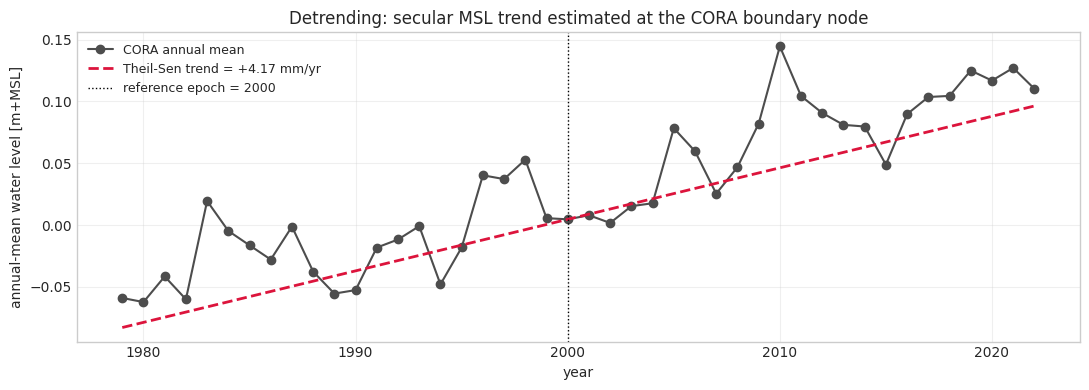

annual_mean_years_used 44
minimum_hours_per_year 6574
detrend_formula H_ref(t) = H(t) - slope * (decimal_year(t) - r...
slope_m_per_year 0.004169
reference_epoch_year 2000.0
Name: detrending_parameters, dtype: object

In [6]:
# mean-sea-level trend used to detrend hourly water levels.
years = annual_waterlevel.index.year.to_numpy(dtype=float)
ref_mask = annual_waterlevel.index.year == int(reference_epoch_year)
anchor = float(annual_waterlevel.loc[ref_mask, "mean"].mean()) if ref_mask.any() else float(annual_waterlevel["mean"].mean())
trend_line = anchor + slope_m_per_year * (years - reference_epoch_year)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(years, annual_waterlevel["mean"].to_numpy(dtype=float), "o-", color="0.3", label="CORA annual mean")
ax.plot(years, trend_line, "--", color="crimson", lw=2, label=f"Theil-Sen trend = {slope_m_per_year*1000:+.2f} mm/yr")
ax.axvline(reference_epoch_year, color="black", ls=":", lw=1, label=f"reference epoch = {reference_epoch_year:.0f}")
ax.set_xlabel("year")
ax.set_ylabel("annual-mean water level [m+MSL]")
ax.set_title("Detrending: secular MSL trend estimated at the CORA boundary node")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "annual_mean_years_used": len(annual_waterlevel),
    "minimum_hours_per_year": min_annual_hours,
    "detrend_formula": "H_ref(t) = H(t) - slope * (decimal_year(t) - reference_epoch)",
    "slope_m_per_year": slope_m_per_year,
    "reference_epoch_year": reference_epoch_year,
}, name="detrending_parameters"))


### 2.2.4 Peaks-over-Threshold Extraction

This plot shows which total-water-level peaks exceed the configured threshold and survive declustering.

Parameters shown:
- Threshold quantile: 0.98.
- Minimum separation: 72 hours for the total-water-level marginal diagnostic.


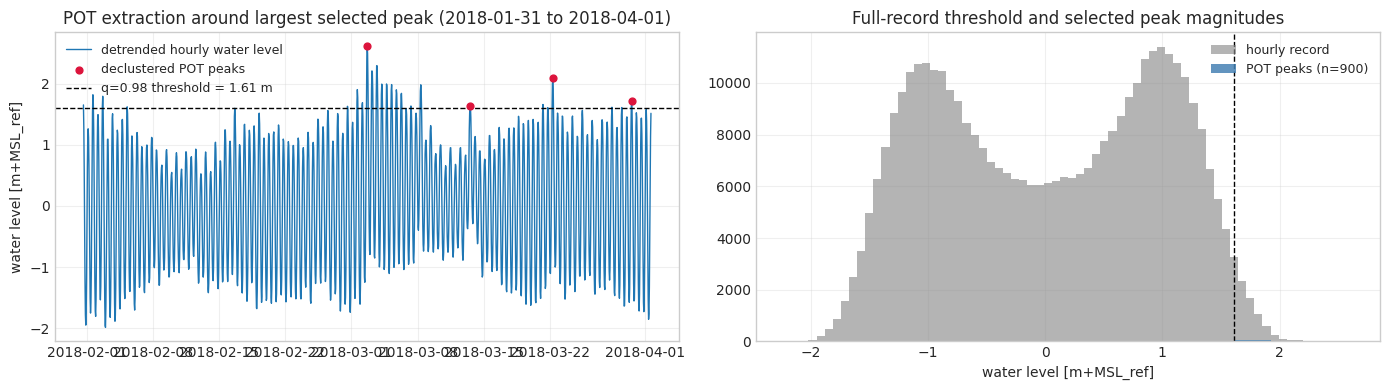

threshold_m_msl_ref 1.612464
independent_peak_events 900.000000
record_years 44.000000
event_rate_per_year 20.455818
tail_region_count_rp_ge_50yr 0.000000
Name: total_water_level_pot, dtype: float64

,peak_water_level_msl_ref,event_time,threshold_m,rank,sample_rp_years,sampling_region
time,,,,,,
1979-01-01 17:00:00,1.826312,1979-01-01 17:00:00,1.612464,415,0.106017,body
1979-01-14 16:00:00,1.649284,1979-01-14 16:00:00,1.612464,807,0.054520,body
1979-01-25 13:00:00,2.330869,1979-01-25 13:00:00,1.612464,8,5.499658,body
1979-02-26 15:00:00,2.242276,1979-02-26 15:00:00,1.612464,15,2.933151,body
1979-03-26 14:00:00,1.824254,1979-03-26 14:00:00,1.612464,428,0.102797,body


In [7]:
# independent coastal peaks from the configured POT threshold.
pot_members = historical_peaks.to_frame(name="peak_water_level_msl_ref").assign(
    event_time=historical_peaks.index,
    threshold_m=threshold_m,
    rank=lambda frame: frame["peak_water_level_msl_ref"].rank(method="first", ascending=False).astype(int),
)
pot_members["sample_rp_years"] = record_years / pot_members["rank"]
pot_members["sampling_region"] = np.where(pot_members["sample_rp_years"] >= 50, "tail", "body")

plot_time = historical_peaks.idxmax()
window_slice = (plot_time - pd.Timedelta(days=30), plot_time + pd.Timedelta(days=30))
window = detrended_waterlevel.loc[window_slice[0]:window_slice[1]]
peak_window = historical_peaks.loc[window_slice[0]:window_slice[1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(window.index, window.values, lw=1.0, label="detrended hourly water level")
axes[0].scatter(peak_window.index, peak_window.values, color="crimson", s=24, zorder=3, label="declustered POT peaks")
axes[0].axhline(threshold_m, color="black", ls="--", lw=1.0, label=f"q={pot_q:.2f} threshold = {threshold_m:.2f} m")
axes[0].set_title(f"POT extraction around largest selected peak ({window_slice[0]:%Y-%m-%d} to {window_slice[1]:%Y-%m-%d})")
axes[0].set_ylabel("water level [m+MSL_ref]")
axes[0].legend(loc="best", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[1].hist(detrended_waterlevel.values, bins=70, color="0.55", alpha=0.65, label="hourly record")
axes[1].hist(historical_peaks.values, bins=35, color="steelblue", alpha=0.85, label=f"POT peaks (n={len(historical_peaks)})")
axes[1].axvline(threshold_m, color="black", ls="--", lw=1.0)
axes[1].set_title("Full-record threshold and selected peak magnitudes")
axes[1].set_xlabel("water level [m+MSL_ref]")
axes[1].legend(loc="best", fontsize=9)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "threshold_m_msl_ref": threshold_m,
    "independent_peak_events": len(pot_members),
    "record_years": round(float(record_years), 2),
    "event_rate_per_year": event_rate_per_year,
    "tail_region_count_rp_ge_50yr": int((pot_members["sampling_region"] == "tail").sum()),
}, name="total_water_level_pot"))
pot_members.head()


### 2.2.5 AIC Model Selection (Exp vs GPD)

The notebook compares candidate tail distributions for threshold exceedances.

Methods:
- Exponential tail has one scale parameter.
- GPD tail has shape and scale parameters.
- Lower `AIC = 2k - 2 log(L)` is preferred, balancing fit and parameter count.


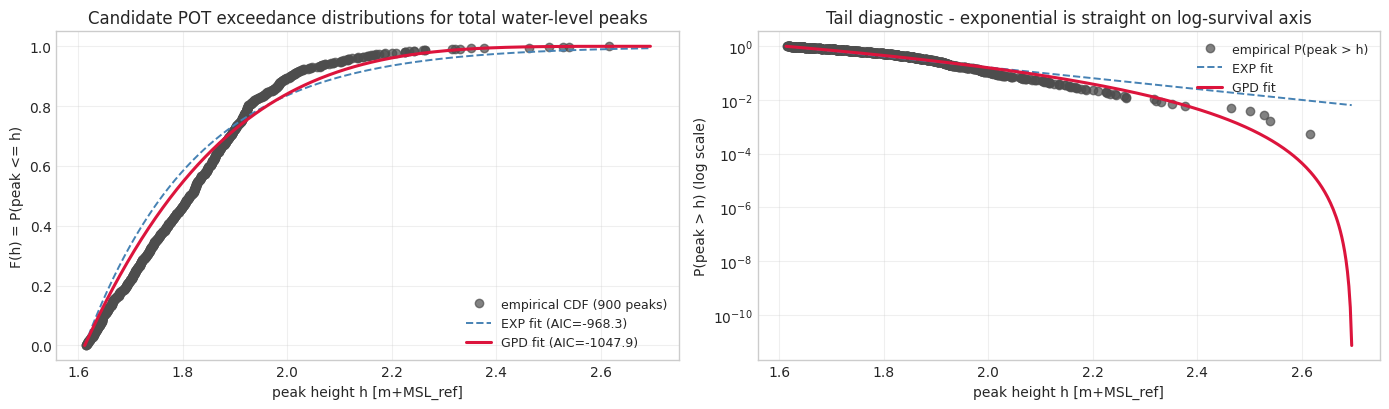

,distribution,shape,loc,scale,aic
0,gpd,-0.2403,0.0,0.2608,-1047.8514
1,exp,0.0000,0.0,0.2146,-968.2826


In [8]:
# exponential/GPD tail-fit comparison for coastal peaks.
sorted_excess = np.sort(peak_exceedances)
grid = np.linspace(0, max(sorted_excess.max() * 1.08, 1e-6), 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(
    sorted_excess + threshold_m,
    np.linspace(0, 1, len(sorted_excess)),
    "o",
    color="0.3",
    alpha=0.7,
    label=f"empirical CDF ({len(sorted_excess):,} peaks)",
)
axes[0].plot(grid + threshold_m, stats.expon.cdf(grid, *exp_params), "--", color="steelblue", lw=1.4, label=f"EXP fit (AIC={exp_aic:.1f})")
axes[0].plot(grid + threshold_m, stats.genpareto.cdf(grid, *gpd_params), "-", color="crimson", lw=2.2, label=f"GPD fit (AIC={gpd_aic:.1f})")
axes[0].set_xlabel("peak height h [m+MSL_ref]")
axes[0].set_ylabel("F(h) = P(peak <= h)")
axes[0].set_title("Candidate POT exceedance distributions for total water-level peaks")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

n = len(sorted_excess)
emp_surv = 1.0 - (np.arange(1, n + 1) - 0.5) / n
axes[1].semilogy(sorted_excess + threshold_m, emp_surv, "o", color="0.3", alpha=0.7, label="empirical P(peak > h)")
axes[1].semilogy(grid + threshold_m, stats.expon.sf(grid, *exp_params), "--", color="steelblue", lw=1.4, label="EXP fit")
axes[1].semilogy(grid + threshold_m, stats.genpareto.sf(grid, *gpd_params), "-", color="crimson", lw=2.2, label="GPD fit")
axes[1].set_xlabel("peak height h [m+MSL_ref]")
axes[1].set_ylabel("P(peak > h) (log scale)")
axes[1].set_title("Tail diagnostic - exponential is straight on log-survival axis")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

display(aic_table.round(4))


### 2.2.6 Return-Period Curve with Bootstrap CI

The fitted marginal is converted to return levels at standard return periods and displayed with bootstrap uncertainty.

- For an annual exceedance rate `lambda`, return period is `T = 1 / (lambda * S(h))`.
- Bootstrap replicates resample the peaks and refit the marginal to estimate confidence intervals.


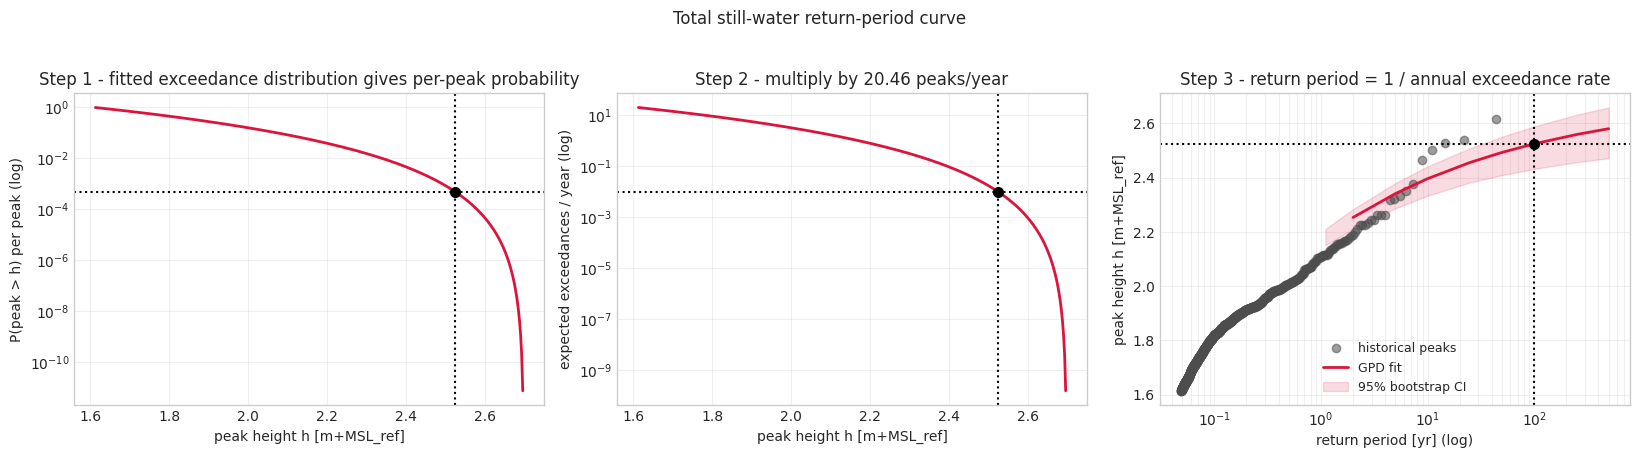

,h_point,h_lo,h_median,h_hi
rps,,,,
1.1,2.1842,2.1499,2.1828,2.2105
2.0,2.2529,2.2114,2.2507,2.2836
5.0,2.3408,2.2867,2.3373,2.3797
10.0,2.3956,2.3329,2.3918,2.4410
25.0,2.4553,2.3816,2.4508,2.5080
50.0,2.4925,2.4089,2.4874,2.5503
100.0,2.5240,2.4317,2.5191,2.5877
250.0,2.5584,2.4562,2.5527,2.6313
500.0,2.5798,2.4710,2.5735,2.6579


In [9]:
# return-period curve and bootstrap uncertainty.
rp_values = np.asarray(extremes_policy["return_periods"], dtype=float)
q_grid = grid + threshold_m
if selected_distribution == "exp":
    annual_exceedance = event_rate_per_year * stats.expon.sf(grid, *exp_params)
else:
    annual_exceedance = event_rate_per_year * stats.genpareto.sf(grid, *gpd_params)
rp_at_h = 1.0 / np.clip(annual_exceedance, 1e-12, None)
per_peak_survival_at_h = annual_exceedance / event_rate_per_year
highlight_rp = 100.0
highlight_h = float(marginal.magnitude(highlight_rp))
highlight_excess = max(highlight_h - threshold_m, 0.0)
if selected_distribution == "exp":
    highlight_per_peak_survival = float(stats.expon.sf(highlight_excess, *exp_params))
else:
    highlight_per_peak_survival = float(stats.genpareto.sf(highlight_excess, *gpd_params))
highlight_annual_rate = 1.0 / highlight_rp
observed = pot_members.sort_values("peak_water_level_msl_ref", ascending=True).copy()
observed["observed_rp_years"] = record_years / np.arange(len(observed), 0, -1)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))
axes[0].semilogy(q_grid, per_peak_survival_at_h, "-", color="crimson", lw=2)
axes[0].axvline(highlight_h, ls=":", color="black")
axes[0].axhline(highlight_per_peak_survival, ls=":", color="black")
axes[0].plot([highlight_h], [highlight_per_peak_survival], "o", color="black", ms=7)
axes[0].set_xlabel("peak height h [m+MSL_ref]")
axes[0].set_ylabel("P(peak > h) per peak (log)")
axes[0].set_title("Step 1 - fitted exceedance distribution gives per-peak probability")
axes[0].grid(True, alpha=0.3, which="both")

axes[1].semilogy(q_grid, annual_exceedance, "-", color="crimson", lw=2)
axes[1].axvline(highlight_h, ls=":", color="black")
axes[1].axhline(highlight_annual_rate, ls=":", color="black")
axes[1].plot([highlight_h], [highlight_annual_rate], "o", color="black", ms=7)
axes[1].set_xlabel("peak height h [m+MSL_ref]")
axes[1].set_ylabel("expected exceedances / year (log)")
axes[1].set_title(f"Step 2 - multiply by {event_rate_per_year:.2f} peaks/year")
axes[1].grid(True, alpha=0.3, which="both")

axes[2].plot(observed["observed_rp_years"], observed["peak_water_level_msl_ref"], "o", color="0.3", alpha=0.55, label="historical peaks")
axes[2].plot(rp_values, marginal.magnitude(rp_values), "-", color="crimson", lw=2, label=f"{selected_distribution.upper()} fit")
if bootstrap is not None:
    cl_pct = int(round(100 * bootstrap["confidence_level"]))
    axes[2].fill_between(bootstrap["rps"], bootstrap["lo"], bootstrap["hi"], color="crimson", alpha=0.15, label=f"{cl_pct}% bootstrap CI")
axes[2].axvline(highlight_rp, ls=":", color="black")
axes[2].axhline(highlight_h, ls=":", color="black")
axes[2].plot([highlight_rp], [highlight_h], "o", color="black", ms=7)
axes[2].set_xscale("log")
axes[2].set_xlabel("return period [yr] (log)")
axes[2].set_ylabel("peak height h [m+MSL_ref]")
axes[2].set_title("Step 3 - return period = 1 / annual exceedance rate")
axes[2].legend(loc="best", fontsize=9)
axes[2].grid(True, alpha=0.3, which="both")
fig.suptitle("Total still-water return-period curve", y=1.03)
fig.tight_layout()
plt.show()

display(pd.concat([
    marginal_rps_frame(marginal, fit_rps).rename(columns={"h": "h_point"}),
    pd.DataFrame({"h_lo": bootstrap["lo"], "h_median": bootstrap["median"], "h_hi": bootstrap["hi"]}, index=pd.Index(fit_rps, name="rps"))
    if bootstrap is not None else pd.DataFrame(index=pd.Index(fit_rps, name="rps")),
], axis=1).round(4))


### 2.2.7 Stationarity Diagnostic on Selected Peaks

This diagnostic checks whether the fitted peak sample has residual time structure after detrending.

Reviewer use:
- A systematic trend after detrending would weaken the assumption that a single historical marginal represents the catalog period.


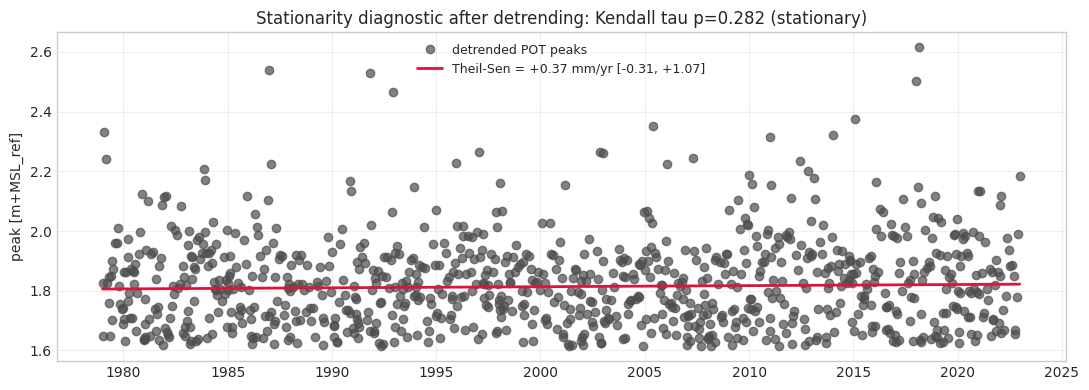

n_peaks 900
mann_kendall_tau 0.023977
mann_kendall_p 0.281533
theil_sen_slope_mm_per_year 0.36634
ols_slope_mm_per_year 0.492457
interpretation stationary
Name: stationarity_after_detrend, dtype: object

In [10]:
# stationarity check for selected coastal peaks.
line_t = np.array([peak_t_years.min(), peak_t_years.max()])
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(historical_peaks.index, peak_values, "o", color="0.3", alpha=0.7, label="detrended POT peaks")
ax.plot(
    [historical_peaks.index.min(), historical_peaks.index.max()],
    peak_trend.intercept + peak_trend.slope * line_t,
    "-",
    color="crimson",
    lw=2,
    label=(
        f"Theil-Sen = {peak_trend.slope*1000:+.2f} mm/yr "
        f"[{peak_trend.low_slope*1000:+.2f}, {peak_trend.high_slope*1000:+.2f}]"
    ),
)
note = "stationary" if stationarity["mann_kendall_p"] >= 0.05 else "trend detected"
ax.set_title(f"Stationarity diagnostic after detrending: Kendall tau p={stationarity['mann_kendall_p']:.3f} ({note})")
ax.set_ylabel("peak [m+MSL_ref]")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "n_peaks": stationarity["n_peaks"],
    "mann_kendall_tau": stationarity["mann_kendall_tau"],
    "mann_kendall_p": stationarity["mann_kendall_p"],
    "theil_sen_slope_mm_per_year": stationarity["theil_sen_slope_m_per_year"] * 1000,
    "ols_slope_mm_per_year": stationarity["ols_slope_m_per_year"] * 1000,
    "interpretation": note,
}, name="stationarity_after_detrend"))


### 2.2.8 Non-Tidal Residual - Coastal Copula Axis (Fix 2)

- Decomposition: `total water level = mean sea level + astronomical tide + NTR`.
- The copula uses NTR and rainfall as meteorological drivers.
- The downstream SFINCS realization rebuilds `MSL + tide + K * NTR`; only NTR is scaled.


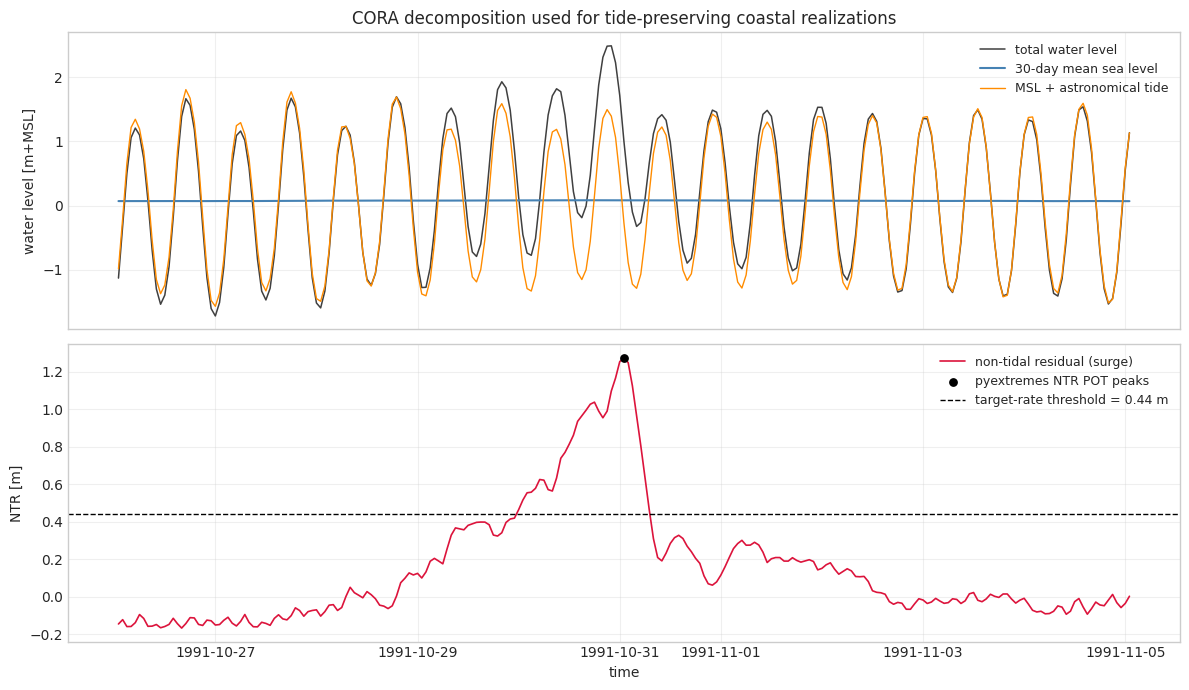

,ntr_return_level_m
rp_years,
2,0.769
10,1.001
50,1.232
100,1.332
500,1.564


decomposition total water level = 30-day MSL + astronomical...
coastal_copula_axis NTR / surge
ntr_threshold_selection target_rate_per_year
ntr_target_rate_per_year 5.0
ntr_threshold_m 0.441256
ntr_min_separation_hours 120.0
ntr_target_peak_count 220
ntr_pot_peaks 213
ntr_event_rate_per_year 4.84121
surge_max_m 1.27432
tide_range_m 3.757425
Name: ntr_coastal_driver, dtype: object

In [11]:
# tide/surge decomposition and NTR dependence setup.
from design_events.fit_history.tidal import coastal_components
# inland/joint design-event catalogs and historical-tail samples.
from design_events.build_events.probability.design_catalog import fit_index_marginal

dependence_policy = {
    "method": "copula_joint",
    "driver_vector": ["coastal_water_level", "rainfall"],
    "primary_driver": "coastal_water_level",
    "event_rate_per_year": 5.0,
    # Copula seed: deterministic joint catalog sampling.
    "copula_seed": 0,
    "pool_size": 100000,
    "enforce_stress_budget": True,
    "catalog_band_fractions": {"mild": 0.05, "common": 0.20, "significant": 0.20, "rare": 0.25, "extreme": 0.30},
    "cooccurrence": {
        "target_rate_per_year": 5.0,
        "condition_on": ["coastal_water_level", "rainfall"],
        "decluster_window_hours": 120,
        "pairing_window_hours": 72,
    },
    "storm_stratification": {
        "enabled": True,
        "centroid": [-70.7, 42.1],
        "radius_km": 350,
        "days_before": 2,
        "days_after": 1,
        "cool_season_months": [10, 11, 12, 1, 2, 3, 4],
        "min_population_events": 20,
    },
    "marginals": {"coastal_water_level": {"kind": "pot"}, "rainfall": {"kind": "pot"}},
    "driver_records": {
        "coastal_water_level": {
            "path": "data/sources/cora_waterlevel/cora_mfield_boundary_hourly_msl.csv",
            "time_column": "time",
            "value_column": "value",
            "transform": "ntr",
            "latitude": 42.1,
        },
        "rainfall": {
            "path": "data/sources/aorc_sst/marshfield/72hr-events/storm-stats.csv",
            "time_column": "storm_date",
            "value_column": "mean",
        },
        "soil_moisture": {
            "path": "data/sources/nwm/soil_moisture.csv",
            "time_column": "time",
            "value_column": "SOILSAT_TOP",
            "aggregate": "mean",
        },
    },
    "member_libraries": {
        "coastal_water_level": {
            "from": "records",
            "index_column": "coastal_peak_m",
        "decluster_window_hours": 120,
        "target_rate_per_year": 5.0,
        },
        "rainfall": {"from": "member_table"},
    },
}
config.setdefault("event_catalog", {})["dependence"] = dependence_policy

coastal_latitude = float(dependence_policy["driver_records"]["coastal_water_level"]["latitude"])
components = coastal_components(waterlevel, latitude=coastal_latitude)

ntr_target_rate_per_year = float(dependence_policy["member_libraries"]["coastal_water_level"]["target_rate_per_year"])
ntr_min_separation_hours = float(dependence_policy["member_libraries"]["coastal_water_level"]["decluster_window_hours"])
ntr_series = components["ntr"].dropna().sort_index()
ntr_record_years = (ntr_series.index[-1] - ntr_series.index[0]).total_seconds() / (365.25 * 86400.0)
ntr_target_peak_count = max(1, int(round(ntr_target_rate_per_year * ntr_record_years)))
ntr_separation = pd.Timedelta(hours=ntr_min_separation_hours)

# Paper-style threshold selection: choose the smallest value among the largest independent
# NTR peaks needed to obtain about 5 exceedances/year, then pass that threshold to pyextremes.
ntr_candidate_values = ntr_series[ntr_series > ntr_series.quantile(0.90)].sort_values(ascending=False, kind="stable")
ntr_selected_times = []
ntr_selected_values = []
for event_time, value in ntr_candidate_values.items():
    if all(abs(event_time - chosen_time) >= ntr_separation for chosen_time in ntr_selected_times):
        ntr_selected_times.append(event_time)
        ntr_selected_values.append(float(value))
        if len(ntr_selected_values) >= ntr_target_peak_count:
            break
ntr_threshold_m = ntr_selected_values[-1]
ntr_extremes = get_extremes(
    ts=ntr_series,
    method="POT",
    threshold=ntr_threshold_m,
    r=ntr_separation,
)
ntr_peaks = ntr_extremes.rename("value").to_frame().rename_axis("time").reset_index()
ntr_rate = len(ntr_peaks) / ntr_record_years
ntr_marginal = fit_index_marginal(ntr_peaks["value"].to_numpy(), event_rate=ntr_rate, kind="pot")

plot_time = pd.Timestamp(ntr_peaks.loc[ntr_peaks["value"].idxmax(), "time"])
window_slice = (plot_time - pd.Timedelta(days=5), plot_time + pd.Timedelta(days=5))
component_window = components.loc[window_slice[0]:window_slice[1]]
ntr_peak_window = ntr_peaks[
    (ntr_peaks["time"] >= window_slice[0]) & (ntr_peaks["time"] <= window_slice[1])
]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(component_window.index, component_window["wl"], label="total water level", color="0.25", lw=1.1)
axes[0].plot(component_window.index, component_window["msl"], label="30-day mean sea level", color="steelblue", lw=1.5)
axes[0].plot(component_window.index, component_window["msl"] + component_window["tide"], label="MSL + astronomical tide", color="darkorange", lw=1.0)
axes[0].set_ylabel("water level [m+MSL]")
axes[0].set_title("CORA decomposition used for tide-preserving coastal realizations")
axes[0].legend(loc="best", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[1].plot(component_window.index, component_window["ntr"], label="non-tidal residual (surge)", color="crimson", lw=1.2)
axes[1].scatter(ntr_peak_window["time"], ntr_peak_window["value"], color="black", s=28, zorder=3, label="pyextremes NTR POT peaks")
axes[1].axhline(ntr_threshold_m, color="black", ls="--", lw=1, label=f"target-rate threshold = {ntr_threshold_m:.2f} m")
axes[1].set_ylabel("NTR [m]")
axes[1].set_xlabel("time")
axes[1].legend(loc="best", fontsize=9)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.DataFrame(
    {"ntr_return_level_m": ntr_marginal.magnitude([2, 10, 50, 100, 500])},
    index=pd.Index([2, 10, 50, 100, 500], name="rp_years"),
).round(3))
display(pd.Series({
    "decomposition": "total water level = 30-day MSL + astronomical tide + NTR",
    "coastal_copula_axis": "NTR / surge",
    "ntr_threshold_selection": "target_rate_per_year",
    "ntr_target_rate_per_year": ntr_target_rate_per_year,
    "ntr_threshold_m": ntr_threshold_m,
    "ntr_min_separation_hours": ntr_min_separation_hours,
    "ntr_target_peak_count": ntr_target_peak_count,
    "ntr_pot_peaks": len(ntr_peaks),
    "ntr_event_rate_per_year": ntr_rate,
    "surge_max_m": float(components["ntr"].max()),
    "tide_range_m": float(components["tide"].max() - components["tide"].min()),
}, name="ntr_coastal_driver"))


## Stage 3 — Per-storm-type copula-joint compound dependence

Assemble the two-sided POT co-occurrence sample over the non-tidal residual (surge) + rainfall drivers. Tag each historical event by storm-type population from HURDAT2 proximity and season, fit a separate vine copula per population, and combine their annual exceedance frequencies.

- Co-occurrence window: ±72 hours between NTR and rainfall events.
- Population model: TC, nor'easter, and other non-tropical populations get separate dependence fits when enough events exist.
- Combined AND return period: `T = 1 / sum_p(lambda_p * S_p(x))`, summing population-specific joint exceedance frequencies.
- Historical driver-severity plot: observed paired drivers are binned by empirical AND return period before any synthetic design set is shown.
- Candidate pool: 100,000 synthetic driver pairs are sampled, then 500 events are selected by configured severity fractions.

## Design Event Catalogue Parameters

 **importance-sampling and resource-allocation design** — Every selected row keeps its `probability_weight`, so enriching this set toward tail-heavy events does not bias the annualised estimate (Average Annual Outcome / EAD) — the weights correct the integral. This allows for oversampling the interesting events without distorting the risk number.

Design event split is user-driven. For this case, a tail-heavy 5/20/20/25/30 split is selected for 500 events.


In [ ]:
# joint catalog sampling policy and event-set selection.
from design_events.fit_history.storm_type import classify_from_config

events_policy = {"target_event_count": 500}
sampling_policy = {
    "spacing": "log",
    "return_period_min_years": 1.5,
    "return_period_max_years": 500.0,
    "hybrid_splice_quantile": 0.95,
    "candidate_pool_count": 100000,
    "tail_sample_fraction": 0.05,
    "catalog_band_fractions": {"mild": 0.05, "common": 0.20, "significant": 0.20, "rare": 0.25, "extreme": 0.30},
    "severity_bands": [
        {"severity_band": "mild", "rp_min_years": 0.0, "rp_max_years": 2.0},
        {"severity_band": "common", "rp_min_years": 2.0, "rp_max_years": 10.0},
        {"severity_band": "significant", "rp_min_years": 10.0, "rp_max_years": 50.0},
        {"severity_band": "rare", "rp_min_years": 50.0, "rp_max_years": 100.0},
        {"severity_band": "extreme", "rp_min_years": 100.0, "rp_max_years": 500.0},
        {"severity_band": "beyond_design", "rp_min_years": 500.0, "rp_max_years": None},
    ],
}
resilience_stress_training = {
    "target_event_count": 500,
    "severity_band_fractions": {"mild": 0.05, "common": 0.20, "significant": 0.20, "rare": 0.25, "extreme": 0.30},
    "benchmark_return_period_years": [10, 50, 100, 500],
    "compound_pairing": {
        "enabled": True,
        "strategy": "operationally_severe_plausible_dependence",
        # Pairing seed: deterministic compound-event allocation.
        "seed": 0,
        "seasonal_window_days": 45,
        "real_event_count": 12,
        "real_event_window_hours": 72,
        "soil_moisture_lead_time_hours": 24,
        "role_fractions": {
            "high_rainfall_cooccurrence": 0.4,
            "rainfall_before_coastal": 0.25,
            "rainfall_after_coastal": 0.25,
            "wet_soil_high_rainfall": 0.1,
        },
    },
}
design_event_policy = {
    "pre_event_baseline_hours": 24,
    "event_threshold_fraction": 0.1,
    "event_threshold_min_m": 0.05,
    "min_event_hours": 12,
    "max_event_hours": 168,
    "tide_resolving_half_window_hours": 72,
    "tail_morph_max_factor": 1.3,
    "tail_morph_trigger_quantile": 0.95,
}
template_assignment_policy = {
    # Template seed: deterministic coastal analog assignment.
    "random_seed": 0,
    "nearest_pool_size": 75,
    "kernel_sigma_scale": 0.5,
    "kernel_sigma_min_m": 0.03,
    "kernel_sigma_max_m": 0.2,
    "reuse_penalty_lambda": 1.0,
    "dominant_peak_ratio_max": 0.9,
}
config["events"] = events_policy
config["sampling"] = sampling_policy
config["resilience_stress_training"] = resilience_stress_training
config["design_events"] = design_event_policy
config["template_assignment"] = template_assignment_policy

joint_paired = assemble_paired_observations_from_config(config, location_root=location_root)
joint_paired = joint_paired.assign(
    storm_type=classify_from_config(joint_paired["event_time"], config, tracks_path=paths["hurdat2_tracks_csv"])
)
joint_driver_vector = config["event_catalog"]["dependence"]["driver_vector"]
historical_driver_u = np.column_stack([
    joint_paired[driver].rank(method="average").to_numpy(dtype=float) / (len(joint_paired) + 1)
    for driver in joint_driver_vector
])
historical_driver_survival = np.clip(np.prod(1 - historical_driver_u, axis=1), 1e-12, None)
historical_driver_rate = float(joint_paired.attrs.get("base_event_rate_per_year", dependence_policy.get("event_rate_per_year", 5.0)))
historical_driver_severity = joint_paired.copy()
historical_driver_severity["sample_rp_years"] = 1.0 / np.clip(historical_driver_rate * historical_driver_survival, 1e-12, None)
historical_driver_severity["severity_band"] = assign_severity_bands(
    historical_driver_severity["sample_rp_years"],
    config["sampling"]["severity_bands"],
)
historical_driver_severity["sampling_weight"] = 1.0

fig = P.plot_severity_bands(historical_driver_severity)
fig.suptitle("Historical paired-driver severity distribution", y=1.03)
plt.show()

display(pd.Series({
    "historical_paired_events": len(historical_driver_severity),
    "driver_vector": ", ".join(joint_driver_vector),
    "cooccurrence_window_hours": dependence_policy["cooccurrence"]["pairing_window_hours"],
    "decluster_window_hours": dependence_policy["cooccurrence"]["decluster_window_hours"],
    "threshold_selection": "target_rate_per_year for each conditioning driver",
    "target_distinct_storm_rate_per_year": dependence_policy["cooccurrence"]["target_rate_per_year"],
    "severity_basis": "empirical paired-driver AND return period",
    "median_historical_driver_rp_years": float(np.nanmedian(historical_driver_severity["sample_rp_years"])),
    "max_historical_driver_rp_years": float(np.nanmax(historical_driver_severity["sample_rp_years"])),
}, name="historical_driver_severity"))

display(pd.Series({
    "copula_engine": "pyvinecopulib",
    "candidate_family_set": ", ".join([
        pvc.BicopFamily.gumbel.name,
        pvc.BicopFamily.clayton.name,
        pvc.BicopFamily.frank.name,
        pvc.BicopFamily.gaussian.name,
        pvc.BicopFamily.student.name,
    ]),
    "candidate_pool_count": dependence_policy["pool_size"],
    "target_event_count": resilience_stress_training["target_event_count"],
    "benchmark_return_periods": resilience_stress_training["benchmark_return_period_years"],
    "severity_band_fractions": resilience_stress_training["severity_band_fractions"],
    "storm_type_populations_enabled": dependence_policy["storm_stratification"]["enabled"],
    "compound_pairing_strategy": resilience_stress_training["compound_pairing"]["strategy"],
}, name="copula_sampling_parameters"))

joint_member_libraries = build_member_libraries(config, location_root=location_root)
joint_result = build_joint_catalog(
    config,
    {"location_root": location_root, "location_name": location_name, "scenario": {"name": "base"}},
    paired_observations=joint_paired,
    member_libraries=joint_member_libraries,
)
joint_catalog = joint_result.catalog
historical_tail_catalog = build_tail(
    joint_paired,
    joint_result.model,
    config,
    {"location_root": location_root, "location_name": location_name, "scenario": {"name": "base"}},
    member_libraries=joint_member_libraries,
)
historical_tail_catalog_path = paths["catalog_root"] / "historical_tail_catalog.csv"
historical_tail_catalog_path.parent.mkdir(parents=True, exist_ok=True)
historical_tail_catalog.to_csv(historical_tail_catalog_path, index=False)
joint_catalog_for_scenarios = pd.concat([joint_catalog, historical_tail_catalog], ignore_index=True, sort=False)
joint_catalog_for_scenarios = attach_antecedent_soil_moisture(
    joint_catalog_for_scenarios, soil_moisture_members, config=config
)

print(
    f"realized base rate {joint_paired.attrs['base_event_rate_per_year']:.2f}/yr "
    f"(threshold calibrated to {joint_paired.attrs['target_rate_per_year']:.0f}/yr over "
    f"{joint_paired.attrs['record_years']:.0f} yr)"
)
display(joint_result.population_report)
display(joint_result.budget_report)

P.plot_storm_type_cooccurrence(joint_paired, joint_driver_vector[0], joint_driver_vector[1]);
P.plot_population_copula_fits(joint_result.model, joint_paired);
P.plot_combined_and_isolines(
    joint_result.model,
    return_periods=resilience_stress_training["benchmark_return_period_years"],
    catalog=joint_catalog,
);
P.plot_tail_budget(joint_catalog, resilience_stress_training);
for _driver in joint_driver_vector:
    P.plot_scaling(joint_catalog, _driver);

pd.Series({
    "paired_observation_rows": len(joint_paired),
    "copula_joint_catalog_rows": len(joint_catalog),
    "historical_tail_rows": len(historical_tail_catalog),
    "scenario_handoff_rows": len(joint_catalog_for_scenarios),
    "driver_vector": ", ".join(joint_driver_vector),
    "storm_type_populations": ", ".join(
        f"{row.storm_type}:{int(row.n_events)}" for row in joint_result.population_report.itertuples()
    ),
    "mixture_total_rate_per_year": round(joint_result.model.total_rate, 2),
    "forcing_pairing_policy": joint_catalog["forcing_pairing_policy"].iloc[0],
    "stress_budget_met": bool(
        joint_result.budget_report.loc[joint_result.budget_report["stress_budget_count"] > 0, "meets_budget"].all()
    ),
    "historical_tail_csv": str(historical_tail_catalog_path),
}, name="copula_joint_summary")


In [ ]:
# annualization rate for downstream FIAT risk.
# The catalog's probability_weight is a normalized mass that sums to 1 over the synthetic
# events; turning it into Expected Annual Damage needs the copula mixture occurrence rate:
#     annual_rate_i = total_rate_per_year * probability_weight_i
# That rate (joint_result.model.total_rate) is otherwise only printed, so write it with
# provenance. No science changes here - this just surfaces an already-computed number.
catalog_risk_metadata = {
    "total_rate_per_year": float(joint_result.model.total_rate),
    "base_event_rate_per_year": float(
        joint_paired.attrs.get("base_event_rate_per_year", dependence_policy.get("event_rate_per_year"))
    ),
    "record_years": float(joint_paired.attrs.get("record_years")),
    "weight_basis": (
        "probability_weight sums to 1 over synthetic events; "
        "annual_rate = total_rate_per_year * probability_weight"
    ),
    "severity_band_fractions": config["resilience_stress_training"]["severity_band_fractions"],
    "event_origins_excluded_from_ead": ["historical_tail"],
    "driver_vector": joint_driver_vector,
}
catalog_risk_metadata_path = paths["catalog_root"] / "catalog_risk_metadata.json"
catalog_risk_metadata_path.write_text(json.dumps(catalog_risk_metadata, indent=2), encoding="utf-8")
display(pd.Series(catalog_risk_metadata, name="catalog_risk_metadata"))

## Stage 4 — Copula-joint design catalog and resilience stress/training set

The fitted candidate pool is audited through severity-band support and probability mass. The selected 500-row design/stress set is intentionally enriched across severity bands for SFINCS/DNMG scenario coverage.

- Unweighted event count shows the run budget allocation.
- `probability_weight` shows the fitted probability mass each enriched row represents.
- Benchmark plots verify coverage near 10, 50, 100, and 500 year driver return periods.

### 4.1 Selected Design Catalog Severity Ranges

mild/common/significant/rare/extreme labels

In [13]:
# severity-band ranges for selected coastal design catalog.
severity_ranges = pd.DataFrame(config["sampling"]["severity_bands"])
severity_ranges["and_joint_return_period_range"] = severity_ranges.apply(
    lambda row: (
        f">= {row['rp_min_years']:g} yr" if pd.isna(row["rp_max_years"])
        else f"{row['rp_min_years']:g} to <{row['rp_max_years']:g} yr"
    ),
    axis=1,
)
severity_ranges["annual_chance_range"] = severity_ranges.apply(
    lambda row: (
        f"<= {100 / row['rp_min_years']:g}%" if pd.isna(row["rp_max_years"]) and row["rp_min_years"] > 0
        else (
            f"> {100 / row['rp_max_years']:g}% to <= {100 / row['rp_min_years']:g}%"
            if row["rp_min_years"] > 0 else f"> {100 / row['rp_max_years']:g}%"
        )
    ),
    axis=1,
)
display(severity_ranges[["severity_band", "and_joint_return_period_range", "annual_chance_range"]])
P.plot_severity_bands(joint_catalog);


,severity_band,and_joint_return_period_range,annual_chance_range
0,mild,0 to <2 yr,> 50%
1,common,2 to <10 yr,> 10% to <= 50%
2,significant,10 to <50 yr,> 2% to <= 10%
3,rare,50 to <100 yr,> 1% to <= 2%
4,extreme,100 to <500 yr,> 0.2% to <= 1%
5,beyond_design,>= 500 yr,<= 0.2%


### 4.2 Resilience Stress/Training Set Coverage

The coastal joint catalog is generated as a 500-event band-stratified importance sample from the fitted candidate pool. This block writes the operational resilience stress/training set and plots its unweighted severity budget alongside the probability-weighted mass represented by those enriched rows.

stress_training_rows 500
sampling_scheme band_stratified_importance
mild_rows 25
mild_fraction 0.05
probability_weight_sum 1.0
stress_training_csv /home/grahamhults/projects/Flood-RM/locations/...
compound_pairing_policy operationally_severe_plausible_dependence
Name: resilience_stress_training, dtype: object

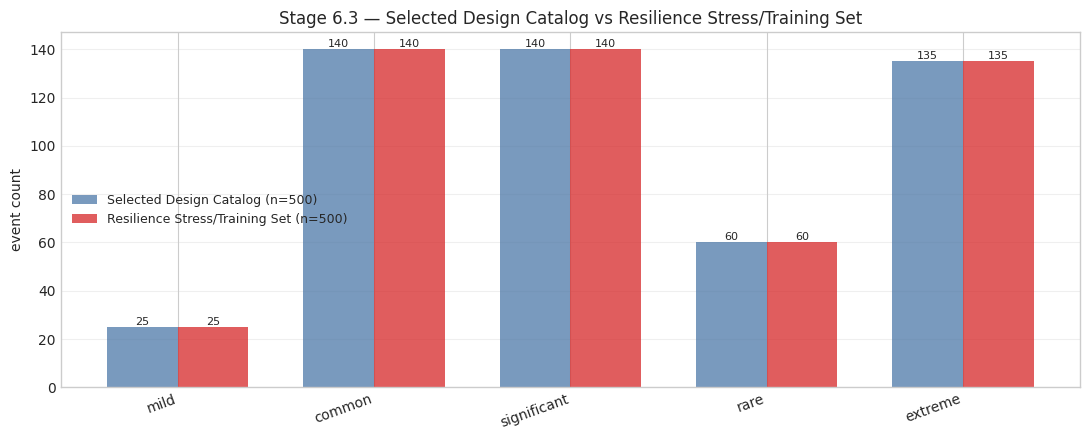

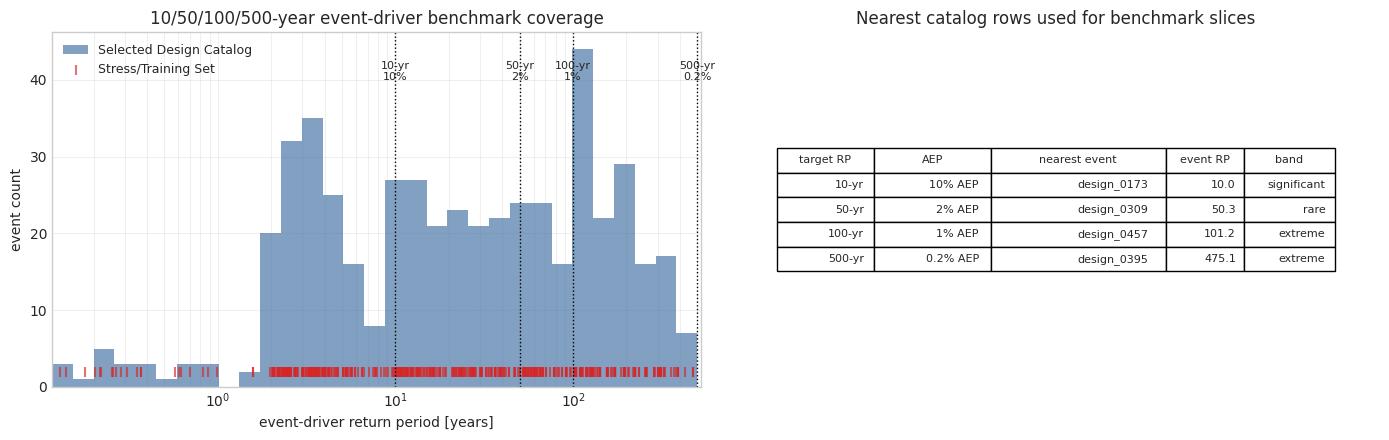

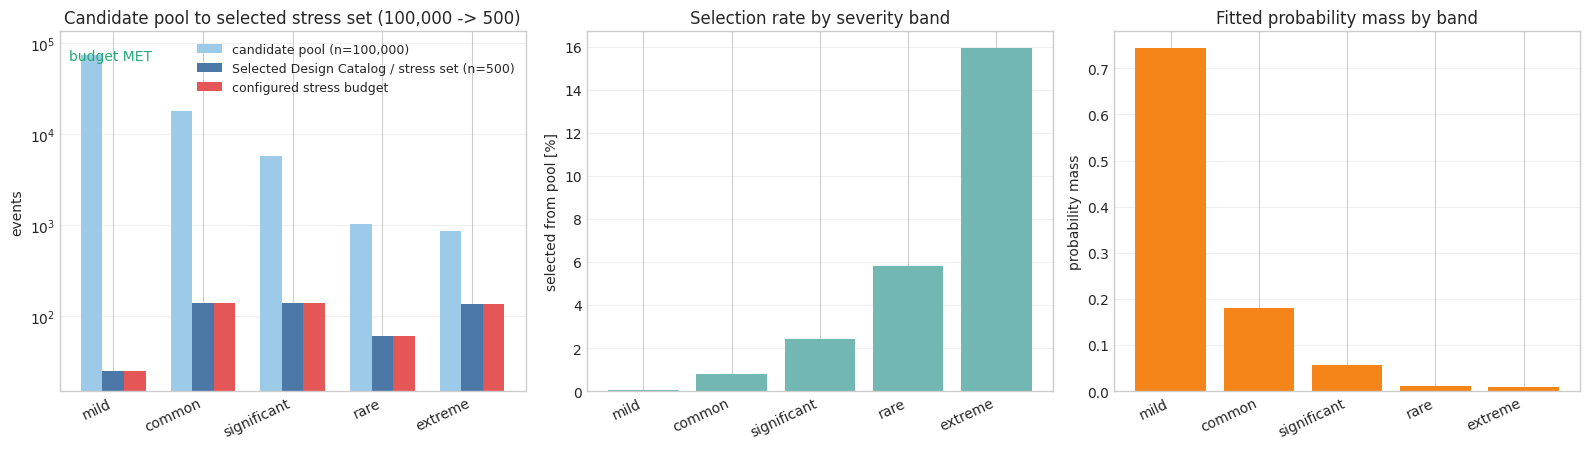

In [14]:
# high-fidelity simulation budget coverage by severity.
benchmark_return_periods = config["resilience_stress_training"]["benchmark_return_period_years"]
stress_training_catalog = select_training(
    joint_catalog,
    rainfall_members=rainfall_members,
    soil_moisture_members=soil_moisture_members,
    config=config,
)
paths["resilience_stress_training_catalog_csv"].parent.mkdir(parents=True, exist_ok=True)
stress_training_catalog.to_csv(paths["resilience_stress_training_catalog_csv"], index=False)

P.plot_severity_bands(stress_training_catalog);
P.plot_catalog_set_severity_comparison(joint_catalog, stress_training_catalog);
P.plot_return_period_benchmark_coverage(
    joint_catalog,
    stress_catalog=stress_training_catalog,
    benchmarks=benchmark_return_periods,
);
P.plot_tail_budget(stress_training_catalog, config["resilience_stress_training"], severity_bands=config["sampling"]["severity_bands"]);

stress_summary = pd.Series({
    "stress_training_rows": len(stress_training_catalog),
    "sampling_scheme": stress_training_catalog.get("sampling_scheme", pd.Series([pd.NA])).dropna().iloc[0]
    if "sampling_scheme" in stress_training_catalog and stress_training_catalog["sampling_scheme"].notna().any() else pd.NA,
    "mild_rows": int((stress_training_catalog["severity_band"] == "mild").sum()),
    "mild_fraction": float((stress_training_catalog["severity_band"] == "mild").mean()),
    "probability_weight_sum": float(pd.to_numeric(stress_training_catalog["probability_weight"], errors="coerce").sum()),
    "stress_training_csv": str(paths["resilience_stress_training_catalog_csv"]),
    "compound_pairing_policy": stress_training_catalog.get("compound_pairing_policy", pd.Series([pd.NA])).dropna().iloc[0]
    if "compound_pairing_policy" in stress_training_catalog and stress_training_catalog["compound_pairing_policy"].notna().any() else pd.NA,
}, name="resilience_stress_training")
display(stress_summary)

stress_preview = stress_training_catalog.assign(
    has_benchmark=stress_training_catalog["benchmark_return_period_years"].notna(),
    is_mild=stress_training_catalog["severity_band"].eq("mild"),
).sort_values(
    ["has_benchmark", "is_mild", "sample_rp_years"],
    ascending=[False, True, False],
)
display(stress_preview[[
    "event_id", "sample_rp_years", "severity_band", "sampling_weight", "probability_weight",
    "benchmark_return_period_years", "selection_reason",
    "compound_pairing_role", "scenario_timing_edge_case", "rainfall_metric_mm",
]].head(16).round({"sample_rp_years": 2, "sampling_weight": 3, "probability_weight": 8}))


### 4.3 Joint Catalog Row Preview

Every row carries the sampled driver values, observed analog member ids, realization scale factors, probability weight, stress-selection metadata, and infiltration treatment that the downstream SFINCS workflow needs.

In [15]:
# selected catalog columns for reviewer scan.
catalog_preview_columns = [
    "event_id", "event_origin", "catalog_role", "scenario_name", "storm_type", "sample_rp_years", "severity_band", "sampling_region",
    "sampling_weight", "probability_weight", "benchmark_return_period_years", "selection_reason",
    "coastal_water_level", "coastal_water_level_member_id",
    "coastal_water_level_template_member_id", "coastal_water_level_scale_factor",
    "rainfall", "rainfall_member_id", "rainfall_scale_factor",
    "forcing_pairing_policy", "event_drivers", "infiltration_treatment",
]
present_columns = [column for column in catalog_preview_columns if column in joint_catalog_for_scenarios.columns]
display(joint_catalog_for_scenarios[present_columns].head(5))

candidate_pool_count = pd.NA
if "candidate_pool_count" in joint_catalog and joint_catalog["candidate_pool_count"].notna().any():
    candidate_pool_count = int(pd.to_numeric(joint_catalog["candidate_pool_count"], errors="coerce").dropna().iloc[0])

display(pd.Series({
    "forcing_pairing_policy": joint_catalog["forcing_pairing_policy"].iloc[0],
    "synthetic_design_rows": len(joint_catalog),
    "historical_tail_rows": len(historical_tail_catalog),
    "handoff_rows": len(joint_catalog_for_scenarios),
    "candidate_pool_count": candidate_pool_count,
    "origin_counts": ", ".join(f"{k}:{v}" for k, v in joint_catalog_for_scenarios["event_origin"].value_counts().items())
    if "event_origin" in joint_catalog_for_scenarios else pd.NA,
    "stress_training_rows": len(stress_training_catalog),
    "stress_training_csv": str(paths["resilience_stress_training_catalog_csv"]),
}, name="joint_catalog_handoff"))

# SFINCS scenario builder contract: write the realized coastal hydrographs and forcing metadata.
sfincs_handoff = write_handoff(joint_catalog_for_scenarios, components, config=config, paths=paths)
display(pd.Series({
    "event_catalog_rows": len(sfincs_handoff["catalog"]),
    "audit_passed": sfincs_handoff["audit"]["passed"],
    "event_members_nc": str(paths["event_members_nc"]),
    "event_catalog_csv": str(paths["event_catalog_csv"]),
}, name="sfincs_scenario_handoff"))


,event_id,event_origin,catalog_role,scenario_name,storm_type,sample_rp_years,severity_band,sampling_region,sampling_weight,probability_weight,benchmark_return_period_years,selection_reason,coastal_water_level,coastal_water_level_member_id,coastal_water_level_template_member_id,coastal_water_level_scale_factor,rainfall,rainfall_member_id,rainfall_scale_factor,forcing_pairing_policy,event_drivers,infiltration_treatment
0,design_0023,synthetic_body,design,base,other_non_tropical,0.116829,mild,body,14.817,0.029719,NaN,NaN,0.055002,coastal_water_level_19901026T230000,coastal_water_level_19901026T230000,0.112299,8.422818,rainfall_marshfield_72h_rank0382,0.124445,copula_joint,"coastal_water_level, rainfall",none
1,design_0022,synthetic_body,design,base,other_non_tropical,0.129805,mild,body,14.817,0.029719,NaN,NaN,0.106963,coastal_water_level_20030109T140000,coastal_water_level_20030109T140000,0.242375,11.406545,rainfall_marshfield_72h_rank0408,0.172276,copula_joint,"coastal_water_level, rainfall",none
2,design_0004,synthetic_body,design,base,other_non_tropical,0.140819,mild,body,14.817,0.029719,NaN,NaN,0.048778,coastal_water_level_20201205T210000,coastal_water_level_20201205T210000,0.098616,28.117453,rainfall_marshfield_72h_rank0376,0.413726,copula_joint,"coastal_water_level, rainfall",none
3,design_0024,synthetic_body,design,base,nor_easter,0.179952,mild,body,14.817,0.029719,NaN,NaN,0.118940,coastal_water_level_19931101T080000,coastal_water_level_19931101T080000,0.269389,40.779016,rainfall_marshfield_72h_rank0388,0.605439,copula_joint,"coastal_water_level, rainfall",none
4,design_0008,synthetic_body,design,base,other_non_tropical,0.204946,mild,body,14.817,0.029719,NaN,NaN,0.123235,coastal_water_level_19870131T170000,coastal_water_level_19870131T170000,0.279283,51.488613,rainfall_marshfield_72h_rank0440,0.807032,copula_joint,"coastal_water_level, rainfall",none


forcing_pairing_policy copula_joint
synthetic_design_rows 500
historical_tail_rows 10
handoff_rows 510
candidate_pool_count 100000
origin_counts synthetic_tail:335, synthetic_body:165, histor...
stress_training_rows 500
stress_training_csv /home/grahamhults/projects/Flood-RM/locations/...
Name: joint_catalog_handoff, dtype: object

event_catalog_rows 510
audit_passed True
event_members_nc /home/grahamhults/projects/Flood-RM/locations/...
event_catalog_csv /home/grahamhults/projects/Flood-RM/locations/...
Name: sfincs_scenario_handoff, dtype: object

## Stage 5 — Hand off to SFINCS (tide-preserving NTR realization + SLR)

The coastal SFINCS water-level boundary is built from the selected catalog. Each event names an observed surge (NTR) analog and a scale factor `K`.

- Only the NTR/surge component is scaled.
- Astronomical tide and mean sea level are added back unscaled, preserving tide-surge phasing.
- SLR scenarios apply a rigid mean-sea-level offset after the event realization.

,slr_offset_m,description,source_baseline_year,projection_year
scenario_name,,,,
base,0.0,Observed MSL record 1979-2022. Baseline refere...,NaN,NaN
noaa_int_2050,0.3,"NOAA 2022 Tech Report, Intermediate scenario,...",2000.0,2050.0
noaa_int_2100,1.1,"NOAA 2022 Tech Report, Intermediate scenario,...",2000.0,2100.0


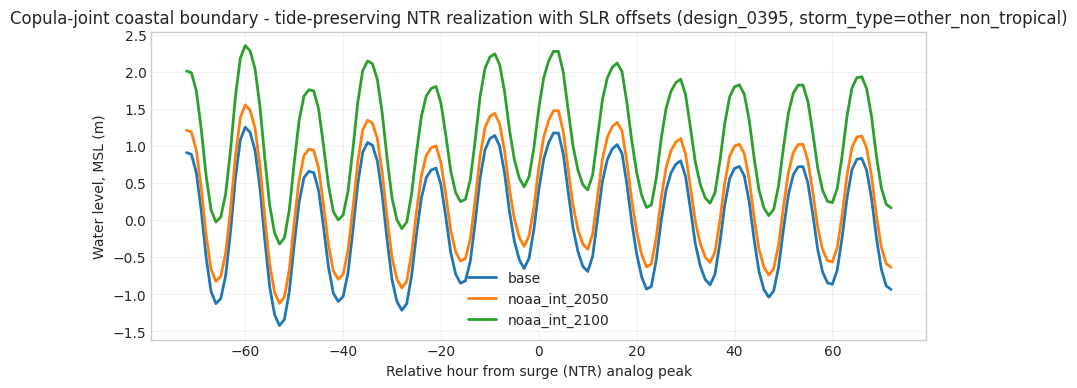

,event_id,sample_rp_years,severity_band,storm_type,ntr_analog_peak_time,ntr_scale_factor,msl_offset_m,peak_water_level_msl
scenario_name,,,,,,,,
base,design_0395,475.08466,extreme,other_non_tropical,1988-11-02T07:00:00,1.017,0.0,1.254
noaa_int_2050,design_0395,475.08466,extreme,other_non_tropical,1988-11-02T07:00:00,1.017,0.3,1.554
noaa_int_2100,design_0395,475.08466,extreme,other_non_tropical,1988-11-02T07:00:00,1.017,1.1,2.354


,base,noaa_int_2050,noaa_int_2100
relative_hour,,,
-72,0.911541,1.211541,2.011541
-71,0.887353,1.187353,1.987353
-70,0.641849,0.941849,1.741849
-69,0.133224,0.433224,1.233224
-68,-0.499825,-0.199825,0.600175
-67,-0.959110,-0.659110,0.140890
-66,-1.125454,-0.825454,-0.025454
-65,-1.056810,-0.756810,0.043190
-64,-0.744018,-0.444018,0.355982


In [16]:
# SFINCS boundary forcing and sea-level-rise scenarios.
from sfincs_runs.scenarios.coastal_realization import build_timeseries

sea_level_rise_scenarios = {
    "base": {"slr_offset_m": 0.0, "description": "Observed MSL record 1979-2022. Baseline reference."},
    "noaa_int_2050": {
        "slr_offset_m": 0.3,
        "description": "NOAA 2022 Tech Report, Intermediate scenario, 2050.",
        "source": "NOAA/NASA Interagency Sea Level Rise Scenario Tool, 2022 Technical Report data",
        "source_url": "https://sealevel.nasa.gov/data_tools/18/",
        "source_dataset": "Global and Regional Sea Level Rise Scenarios for the United States: Updated Mean Projections and Extreme Water Level Probabilities Along U.S. Coastlines",
        "source_location_basis": "regional/local relative sea-level scenario applicable to Massachusetts South Shore; not a Boston tide-gauge detrend",
        "source_baseline_year": 2000,
        "source_accessed": "2026-05-01",
        "scenario_family": "Intermediate",
        "projection_year": 2050,
    },
    "noaa_int_2100": {
        "slr_offset_m": 1.1,
        "description": "NOAA 2022 Tech Report, Intermediate scenario, 2100.",
        "source": "NOAA/NASA Interagency Sea Level Rise Scenario Tool, 2022 Technical Report data",
        "source_url": "https://sealevel.nasa.gov/data_tools/18/",
        "source_dataset": "Global and Regional Sea Level Rise Scenarios for the United States: Updated Mean Projections and Extreme Water Level Probabilities Along U.S. Coastlines",
        "source_location_basis": "regional/local relative sea-level scenario applicable to Massachusetts South Shore; not a Boston tide-gauge detrend",
        "source_baseline_year": 2000,
        "source_accessed": "2026-05-01",
        "scenario_family": "Intermediate",
        "projection_year": 2100,
    },
}
config["scenarios"] = sea_level_rise_scenarios

scenario_table = pd.DataFrame.from_dict(sea_level_rise_scenarios, orient="index")
scenario_table.index.name = "scenario_name"
scenario_table["slr_offset_m"] = pd.to_numeric(scenario_table["slr_offset_m"], errors="coerce").fillna(0.0)
display(scenario_table[["slr_offset_m", "description", "source_baseline_year", "projection_year"]])

example_row = joint_catalog.sort_values("sample_rp_years", ascending=False).iloc[0]
scenario_forcings = {
    name: build_timeseries(example_row, components, msl_offset_m=float(row["slr_offset_m"]))
    for name, row in scenario_table.iterrows()
}
slr_forcing_frame = pd.concat(
    {name: forcing["h"].rename(name) for name, forcing in scenario_forcings.items()},
    axis=1,
)

ax = slr_forcing_frame.plot(figsize=(10, 4), linewidth=2)
ax.set_title(
    f"Copula-joint coastal boundary - tide-preserving NTR realization with SLR offsets "
    f"({example_row['event_id']}, storm_type={example_row.get('storm_type', 'n/a')})"
)
ax.set_xlabel("Relative hour from surge (NTR) analog peak")
ax.set_ylabel("Water level, MSL (m)")
ax.grid(True, alpha=0.25)
plt.show()

display(pd.DataFrame({
    "event_id": str(example_row["event_id"]),
    "sample_rp_years": float(example_row["sample_rp_years"]),
    "severity_band": str(example_row["severity_band"]),
    "storm_type": str(example_row.get("storm_type", "n/a")),
    "ntr_analog_peak_time": {name: forcing["analog_peak_time"] for name, forcing in scenario_forcings.items()},
    "ntr_scale_factor": {name: round(forcing["scale_factor"], 3) for name, forcing in scenario_forcings.items()},
    "msl_offset_m": {name: forcing["msl_offset_m"] for name, forcing in scenario_forcings.items()},
    "peak_water_level_msl": slr_forcing_frame.max().round(3),
}).rename_axis("scenario_name"))
slr_forcing_frame.head(12)
